Running the sample data

In [1]:
import pandas as pd
acc = pd.read_csv("sample_data/sample_data/2_PocketPhone_Accelerometer_(Samsung_S6).csv")
gyr = pd.read_csv("sample_data/sample_data/2_PocketPhone_Gyroscope_(Samsung_S6).csv")

acc.head(), gyr.head()

(   EID    Xvalue     Yvalue    Zvalue                     time
 0    0  1.978808  -1.114501  3.514688  2017-04-17 14:44:43.026
 1    1  0.810437  -2.832341  2.801216  2017-04-17 14:44:43.036
 2    2 -0.252588  -5.337873  2.322376  2017-04-17 14:44:43.045
 3    3 -1.994370  -8.580819  0.926556  2017-04-17 14:44:43.057
 4    4 -3.323152 -11.498154 -0.196325  2017-04-17 14:44:43.066,
    EID    Xvalue    Yvalue    Zvalue                     time
 0    0  0.579504 -0.647681  0.233293  2017-04-17 14:44:43.026
 1    1  1.075917 -1.181378  0.243946  2017-04-17 14:44:43.036
 2    2  1.538242 -1.643703  0.274838  2017-04-17 14:44:43.045
 3    3  1.940912 -1.842908  0.297209  2017-04-17 14:44:43.057
 4    4  2.179531 -1.902562  0.373908  2017-04-17 14:44:43.066)

Next we format the two tables so when we output we can know which value is which when combining such as Accelerometer x,y,z and Gyroscope x,y,z

In [2]:
# format accelerometer
acc = acc.rename(columns={
    "Xvalue": "x",
    "Yvalue": "y",
    "Zvalue": "z"
})

# format gyroscope
gyr = gyr.rename(columns={
    "Xvalue": "x",
    "Yvalue": "y",
    "Zvalue": "z"
})

# convert timestamps
acc["time"] = pd.to_datetime(acc["time"], errors="coerce")
gyr["time"] = pd.to_datetime(gyr["time"], errors="coerce")

# keep only useful columns, remove bad rows, sort by time
acc = acc[["time", "x", "y", "z"]].dropna().sort_values("time").reset_index(drop=True)
gyr = gyr[["time", "x", "y", "z"]].dropna().sort_values("time").reset_index(drop=True)

print(acc.head())
print(gyr.head())
print(acc.shape, gyr.shape)

                     time         x          y         z
0 2017-04-17 14:44:43.026  1.978808  -1.114501  3.514688
1 2017-04-17 14:44:43.036  0.810437  -2.832341  2.801216
2 2017-04-17 14:44:43.045 -0.252588  -5.337873  2.322376
3 2017-04-17 14:44:43.057 -1.994370  -8.580819  0.926556
4 2017-04-17 14:44:43.066 -3.323152 -11.498154 -0.196325
                     time         x         y         z
0 2017-04-17 14:44:43.026  0.579504 -0.647681  0.233293
1 2017-04-17 14:44:43.036  1.075917 -1.181378  0.243946
2 2017-04-17 14:44:43.045  1.538242 -1.643703  0.274838
3 2017-04-17 14:44:43.057  1.940912 -1.842908  0.297209
4 2017-04-17 14:44:43.066  2.179531 -1.902562  0.373908
(35105, 4) (35105, 4)


Combine accelerometer + gyroscope into one 6-channel stream

In [3]:
merged = pd.merge_asof(
    acc.sort_values("time"),
    gyr.sort_values("time"),
    on="time",
    suffixes=("_acc", "_gyr")
)

merged = merged.rename(columns={
    "x_acc":"acc_x",
    "y_acc":"acc_y",
    "z_acc":"acc_z",
    "x_gyr":"gyr_x",
    "y_gyr":"gyr_y",
    "z_gyr":"gyr_z"
})

merged.head()

,time,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
0,2017-04-17 14:44:43.026,1.978808,-1.114501,3.514688,0.579504,-0.647681,0.233293
1,2017-04-17 14:44:43.036,0.810437,-2.832341,2.801216,1.075917,-1.181378,0.243946
2,2017-04-17 14:44:43.045,-0.252588,-5.337873,2.322376,1.538242,-1.643703,0.274838
3,2017-04-17 14:44:43.057,-1.994370,-8.580819,0.926556,1.940912,-1.842908,0.297209
4,2017-04-17 14:44:43.066,-3.323152,-11.498154,-0.196325,2.179531,-1.902562,0.373908


Resampling the merged 6 channel stream to 100 hz

In [4]:
# set time as index
merged = merged.set_index("time").sort_index()

# if duplicate timestamps exist, average them
merged = merged.groupby(level=0).mean()

# resample to 100 Hz = every 10 milliseconds
merged_100hz = merged.resample("10ms").mean().interpolate(limit_direction="both")

print(merged_100hz.head())
print("Resampled shape:", merged_100hz.shape)


                            acc_x      acc_y     acc_z     gyr_x     gyr_y  \
time                                                                         
2017-04-17 14:44:43.020  1.978808  -1.114501  3.514688  0.579504 -0.647681   
2017-04-17 14:44:43.030  0.810437  -2.832341  2.801216  1.075917 -1.181378   
2017-04-17 14:44:43.040 -0.252588  -5.337873  2.322376  1.538242 -1.643703   
2017-04-17 14:44:43.050 -1.994370  -8.580819  0.926556  1.940912 -1.842908   
2017-04-17 14:44:43.060 -3.323152 -11.498154 -0.196325  2.179531 -1.902562   

                            gyr_z  
time                               
2017-04-17 14:44:43.020  0.233293  
2017-04-17 14:44:43.030  0.243946  
2017-04-17 14:44:43.040  0.274838  
2017-04-17 14:44:43.050  0.297209  
2017-04-17 14:44:43.060  0.373908  
Resampled shape: (200841, 6)


Apply a sliding window approach to segment the continuous time-series data into fixed-size samples. 100 Hz and 5 seconds = 500 and we use 6 channels for acc & gyr (x,y,z)

In [5]:
import numpy as np

WIN = 500   # 5 seconds at 100 Hz
HOP = 250   # 50% overlap

X6 = merged_100hz[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].to_numpy(dtype=float)

windows = []
for i in range(0, len(X6) - WIN + 1, HOP):
    windows.append(X6[i:i+WIN])

windows = np.array(windows)

print("Windows shape:", windows.shape)

Windows shape: (802, 500, 6)


Data cleaning & Analysis, here we clean then visualize a few different users 

In [6]:
import numpy as np

def moving_average_1d(signal, k=5):
    return np.convolve(signal, np.ones(k)/k, mode="same")

def smooth_window(window, k=5):
    smoothed = np.zeros_like(window)
    
    for ch in range(window.shape[1]):   # loop through 6 channels
        smoothed[:, ch] = moving_average_1d(window[:, ch], k)
        
    return smoothed

# apply smoothing to all windows
windows_clean = np.array([smooth_window(w, k=5) for w in windows])

print("Cleaned windows shape:", windows_clean.shape)

Cleaned windows shape: (802, 500, 6)


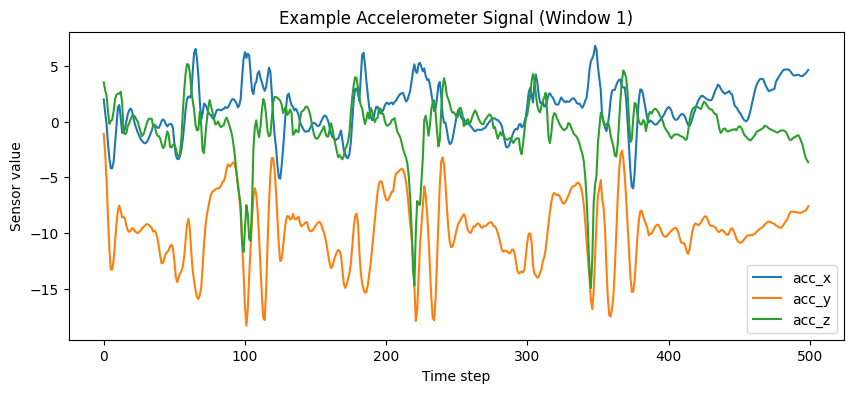

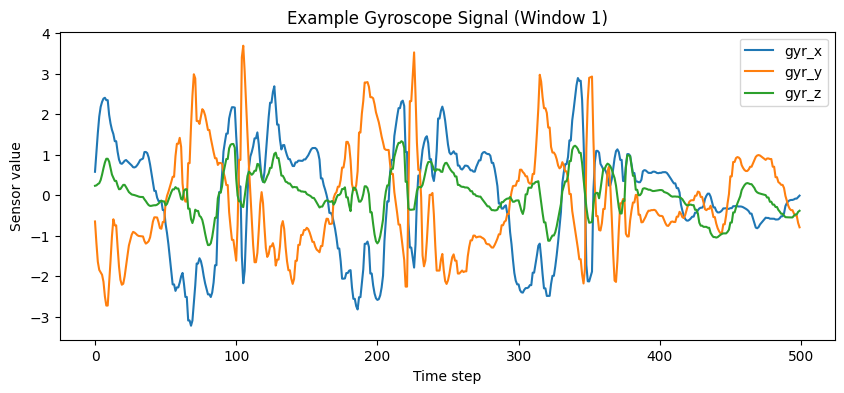

In [7]:
import matplotlib.pyplot as plt

# plot the first window
plt.figure(figsize=(10,4))
plt.plot(windows[0,:,0], label="acc_x")
plt.plot(windows[0,:,1], label="acc_y")
plt.plot(windows[0,:,2], label="acc_z")

plt.title("Example Accelerometer Signal (Window 1)")
plt.xlabel("Time step")
plt.ylabel("Sensor value")
plt.legend()
plt.show()

# Gyroscope signals
plt.figure(figsize=(10,4))
plt.plot(windows[0,:,3], label="gyr_x")
plt.plot(windows[0,:,4], label="gyr_y")
plt.plot(windows[0,:,5], label="gyr_z")

plt.title("Example Gyroscope Signal (Window 1)")
plt.xlabel("Time step")
plt.ylabel("Sensor value")
plt.legend()
plt.show()

The first graph shows accelerometer which is movements on 3 different planes x,y,z. acc_y reaches around -16 which means there is big movement or noise.

The second graph shows Gyroscope signals which is like the rotation of the phone. theres also 3 different planes as well x,y,z. 

On the graphs we see sudden spikes and high irregular fluctuations up and downs

To clean the data, the method I would justify using to help reduce noise is Moving Average smoothing. It would be applied to each sensor channel within its windows. A moving average filter with a window size of 5 samples was used to smooth the signals by averaging the neighboring values. This will reduce short term noises while keeping the shape and patterns of the motion.

## 2.1 Feedfoward Neural Network (FNN) Approach


In [8]:
import pandas as pd
import numpy as np

# 10 user IDs from your dataset
user_ids = [2, 13, 23, 24, 49, 52, 55, 70, 78, 112]

def moving_average_1d(signal, k=5):
    return np.convolve(signal, np.ones(k) / k, mode="same")

def smooth_window(window, k=5):
    smoothed = np.zeros_like(window)
    for ch in range(window.shape[1]):
        smoothed[:, ch] = moving_average_1d(window[:, ch], k)
    return smoothed

def process_user(acc_path, gyr_path, max_windows=150):
    # load CSVs
    acc = pd.read_csv(acc_path)
    gyr = pd.read_csv(gyr_path)

    # format columns
    acc = acc.rename(columns={"Xvalue": "x", "Yvalue": "y", "Zvalue": "z"})
    gyr = gyr.rename(columns={"Xvalue": "x", "Yvalue": "y", "Zvalue": "z"})

    acc["time"] = pd.to_datetime(acc["time"], errors="coerce")
    gyr["time"] = pd.to_datetime(gyr["time"], errors="coerce")

    acc = acc[["time", "x", "y", "z"]].dropna().sort_values("time").reset_index(drop=True)
    gyr = gyr[["time", "x", "y", "z"]].dropna().sort_values("time").reset_index(drop=True)

    # merge accelerometer + gyroscope into 6 channels
    merged = pd.merge_asof(
        acc.sort_values("time"),
        gyr.sort_values("time"),
        on="time",
        suffixes=("_acc", "_gyr"),
        direction="nearest"
    )

    merged = merged.rename(columns={
        "x_acc": "acc_x",
        "y_acc": "acc_y",
        "z_acc": "acc_z",
        "x_gyr": "gyr_x",
        "y_gyr": "gyr_y",
        "z_gyr": "gyr_z"
    })

    merged = merged[["time", "acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].dropna()

    # resample to 100 Hz
    merged = merged.set_index("time").sort_index()
    merged = merged.groupby(level=0).mean()
    merged_100hz = merged.resample("10ms").mean().interpolate(limit_direction="both")

    # windowing: 5 sec at 100 Hz = 500 samples, 50% overlap = 250 hop
    WIN = 500
    HOP = 250

    X6 = merged_100hz[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].to_numpy(dtype=float)

    windows = []
    for i in range(0, len(X6) - WIN + 1, HOP):
        windows.append(X6[i:i+WIN])
        if len(windows) >= max_windows:   # keep about 150 per user
            break

    windows = np.array(windows)

    # moving average smoothing
    windows_clean = np.array([smooth_window(w, k=5) for w in windows])

    return windows_clean

# build dataset for all 10 users
X_list = []
y_list = []

for uid in user_ids:
    acc_path = f"sample_data/sample_data/{uid}_PocketPhone_Accelerometer_(Samsung_S6).csv"
    gyr_path = f"sample_data/sample_data/{uid}_PocketPhone_Gyroscope_(Samsung_S6).csv"

    user_windows = process_user(acc_path, gyr_path, max_windows=150)

    X_list.append(user_windows)
    y_list.extend([uid] * len(user_windows))

    print(f"User {uid}: {user_windows.shape}")

X_all = np.concatenate(X_list, axis=0)
y_all = np.array(y_list)

# encode labels 0-9 for multiclass classification
label_map = {uid: i for i, uid in enumerate(user_ids)}
y_encoded = np.array([label_map[uid] for uid in y_all])

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Encoded labels:", np.unique(y_encoded))
print("Label map:", label_map)


User 2: (150, 500, 6)
User 13: (150, 500, 6)
User 23: (150, 500, 6)
User 24: (150, 500, 6)
User 49: (150, 500, 6)
User 52: (150, 500, 6)
User 55: (150, 500, 6)
User 70: (150, 500, 6)
User 78: (150, 500, 6)
User 112: (150, 500, 6)
X_all shape: (1500, 500, 6)
y_all shape: (1500,)
Encoded labels: [0 1 2 3 4 5 6 7 8 9]
Label map: {2: 0, 13: 1, 23: 2, 24: 3, 49: 4, 52: 5, 55: 6, 70: 7, 78: 8, 112: 9}


In [9]:
import numpy as np
from scipy.stats import skew, kurtosis

def extract_channel_features(signal):
    feats = []

    # statistical features
    feats.append(np.mean(signal))
    feats.append(np.std(signal))
    feats.append(np.var(signal))
    feats.append(np.min(signal))
    feats.append(np.max(signal))
    feats.append(np.max(signal) - np.min(signal))  # range
    feats.append(np.percentile(signal, 75) - np.percentile(signal, 25))  # IQR
    feats.append(skew(signal))
    feats.append(kurtosis(signal))
    feats.append(np.mean(np.abs(signal)))  # mean absolute deviation

    # zero crossing rate
    zero_cross = np.mean(np.diff(np.sign(signal)) != 0)
    feats.append(zero_cross)

    # frequency-domain features
    fft_vals = np.abs(np.fft.rfft(signal))
    feats.append(np.max(fft_vals))         # dominant frequency magnitude
    feats.append(np.sum(fft_vals ** 2))    # spectral energy

    return feats

features_all = []

for w in X_all:
    window_features = []
    for ch in range(6):
        signal = w[:, ch]
        window_features.extend(extract_channel_features(signal))
    features_all.append(window_features)

features_all = np.array(features_all)

print("Feature matrix shape:", features_all.shape)
print("Labels shape:", y_encoded.shape)
print("Number of classes:", len(np.unique(y_encoded)))

Feature matrix shape: (1500, 78)
Labels shape: (1500,)
Number of classes: 10


Here we did 13 features x 6 channels which equals to 78 features. we have:
mean
std
variance
min
max
range
IQR
skew
kurtosis
Mean absoulte deviation
zero crossing rate
FFT dominant magnitude
spectral energy

1500 samples because 150 x 10 users = 1500

## 2.2 Feature Subset Selection: Use a suitable feature selection method to reduce the feature set from 20+ down to the best 10 features. 

We use SelectKBest to select the 10 best features

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

# select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(features_all, y_encoded)

print("Original feature shape:", features_all.shape)
print("Reduced feature shape:", X_selected.shape)

# which features were selected
selected_indices = selector.get_support(indices=True)
print("Selected feature indices:", selected_indices)

Original feature shape: (1500, 78)
Reduced feature shape: (1500, 10)
Selected feature indices: [ 0 13 16 17 35 37 38 61 64 65]


The SelectKBest method with the ANOVA F-value scoring function was used after extracting 78 features from each window, feature selection was used to reduce the dataset and only keep the important features. This method evaluates each feature individually by measuring the ratio of between class variance to within class variance, which indicates how well a feature separates different user classes. 

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (1500, 10)


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

accs = []
reports = []
cms = []
loss_curves = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_selected, y_encoded), start=1):
    Xtr, Xte = X_selected[train_idx], X_selected[test_idx]
    ytr, yte = y_encoded[train_idx], y_encoded[test_idx]

    # scale features
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    # FNN model
    mlp = MLPClassifier(
        hidden_layer_sizes=(5, 5),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=0
    )

    mlp.fit(Xtr_s, ytr)
    yp = mlp.predict(Xte_s)

    acc = accuracy_score(yte, yp)
    accs.append(acc)
    reports.append(classification_report(yte, yp, output_dict=True, zero_division=0))
    cms.append(confusion_matrix(yte, yp))
    loss_curves.append(mlp.loss_curve_)

    print(f"Fold {fold} accuracy: {acc:.4f}")

print(f"\nMean accuracy over {kf.get_n_splits()} folds: {np.mean(accs):.4f}")
print(f"Std accuracy over {kf.get_n_splits()} folds: {np.std(accs):.4f}")

c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1 accuracy: 0.9533


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 2 accuracy: 0.8233


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 3 accuracy: 0.9300


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 4 accuracy: 0.8633
Fold 5 accuracy: 0.9300

Mean accuracy over 5 folds: 0.9000
Std accuracy over 5 folds: 0.0487


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


The FNN was implemented using scikit-learn’s MLPClassifier. The network used 10 input corresponding to the selected features, followed by two hidden layers with 5 neurons each using ReLU activation function. The output layer performed 10-class classification to identify the user. Before training, all features were standardized using StandardScaler. Model performance was evaluated using 5-fold Stratified Cross-Validation, getting an average accuracy of 90.0%.

LSTM


In [13]:
import numpy as np
from sklearn.preprocessing import StandardScaler

N, T, F = X_all.shape

scaler_seq = StandardScaler()
X_2d = X_all.reshape(-1, F)              # (N*T, 6)
X_2d_scaled = scaler_seq.fit_transform(X_2d)
X_lstm = X_2d_scaled.reshape(N, T, F)

print("LSTM input shape:", X_lstm.shape)
print("Labels shape:", y_encoded.shape)

LSTM input shape: (1500, 500, 6)
Labels shape: (1500,)


In [14]:
import torch
print(torch.__version__)

2.10.0+cpu


In [15]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=6, hidden_size=6, num_layers=2, num_classes=10):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last timestep
        out = self.fc(out)
        return out

In [16]:
import torch

X_tensor = torch.tensor(X_lstm, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_tensor = torch.tensor(X_lstm, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

epochs = 30
batch_size = 64

train_losses = []
val_losses = []
train_accs = []
val_accs = []

cms = []            # confusion matrices
precisions = []
recalls = []
f1s = []

for fold,(train_idx,test_idx) in enumerate(kf.split(X_lstm,y_encoded)):

    print("\n=== Fold", fold+1, "===")

    Xtr = X_tensor[train_idx]
    Xte = X_tensor[test_idx]
    ytr = y_tensor[train_idx]
    yte = y_tensor[test_idx]

    model = LSTMModel()

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    fold_train_loss = []
    fold_val_loss = []
    fold_train_acc = []
    fold_val_acc = []

    for epoch in range(epochs):

        model.train()

        perm = torch.randperm(Xtr.size(0))

        for i in range(0, Xtr.size(0), batch_size):

            idx = perm[i:i+batch_size]

            batch_x = Xtr[idx]
            batch_y = ytr[idx]

            optimizer.zero_grad()

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            loss.backward()
            optimizer.step()

        # evaluation
        model.eval()

        with torch.no_grad():

            train_preds = model(Xtr)
            train_loss = criterion(train_preds, ytr).item()
            train_pred_labels = torch.argmax(train_preds, dim=1)
            train_acc = (train_pred_labels == ytr).float().mean().item()

            val_preds = model(Xte)
            val_loss = criterion(val_preds, yte).item()
            val_pred_labels = torch.argmax(val_preds, dim=1)
            val_acc = (val_pred_labels == yte).float().mean().item()

        fold_train_loss.append(train_loss)
        fold_val_loss.append(val_loss)
        fold_train_acc.append(train_acc)
        fold_val_acc.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_acc={train_acc:.3f} | val_acc={val_acc:.3f}")

    # ----- AFTER TRAINING THIS FOLD -----

    p, r, f1, _ = precision_recall_fscore_support(
        yte.cpu().numpy(),
        val_pred_labels.cpu().numpy(),
        average="macro",
        zero_division=0
    )

    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

    cm = confusion_matrix(yte.cpu().numpy(), val_pred_labels.cpu().numpy())
    cms.append(cm)

    print(classification_report(yte.cpu().numpy(), val_pred_labels.cpu().numpy()))

    train_losses.append(fold_train_loss)
    val_losses.append(fold_val_loss)
    train_accs.append(fold_train_acc)
    val_accs.append(fold_val_acc)



=== Fold 1 ===
Epoch 1/30 | train_acc=0.099 | val_acc=0.097
Epoch 2/30 | train_acc=0.096 | val_acc=0.097
Epoch 3/30 | train_acc=0.100 | val_acc=0.097
Epoch 4/30 | train_acc=0.243 | val_acc=0.267
Epoch 5/30 | train_acc=0.192 | val_acc=0.200
Epoch 6/30 | train_acc=0.270 | val_acc=0.273
Epoch 7/30 | train_acc=0.216 | val_acc=0.213
Epoch 8/30 | train_acc=0.398 | val_acc=0.393
Epoch 9/30 | train_acc=0.343 | val_acc=0.370
Epoch 10/30 | train_acc=0.366 | val_acc=0.380
Epoch 11/30 | train_acc=0.529 | val_acc=0.523
Epoch 12/30 | train_acc=0.491 | val_acc=0.483
Epoch 13/30 | train_acc=0.517 | val_acc=0.507
Epoch 14/30 | train_acc=0.456 | val_acc=0.450
Epoch 15/30 | train_acc=0.537 | val_acc=0.540
Epoch 16/30 | train_acc=0.544 | val_acc=0.537
Epoch 17/30 | train_acc=0.519 | val_acc=0.503
Epoch 18/30 | train_acc=0.530 | val_acc=0.533
Epoch 19/30 | train_acc=0.536 | val_acc=0.533
Epoch 20/30 | train_acc=0.569 | val_acc=0.557
Epoch 21/30 | train_acc=0.577 | val_acc=0.577
Epoch 22/30 | train_acc=0.5

c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Epoch 1/30 | train_acc=0.117 | val_acc=0.120
Epoch 2/30 | train_acc=0.123 | val_acc=0.120
Epoch 3/30 | train_acc=0.127 | val_acc=0.127
Epoch 4/30 | train_acc=0.229 | val_acc=0.243
Epoch 5/30 | train_acc=0.308 | val_acc=0.317
Epoch 6/30 | train_acc=0.312 | val_acc=0.320
Epoch 7/30 | train_acc=0.346 | val_acc=0.350
Epoch 8/30 | train_acc=0.418 | val_acc=0.420
Epoch 9/30 | train_acc=0.428 | val_acc=0.433
Epoch 10/30 | train_acc=0.488 | val_acc=0.493
Epoch 11/30 | train_acc=0.498 | val_acc=0.490
Epoch 12/30 | train_acc=0.451 | val_acc=0.433
Epoch 13/30 | train_acc=0.463 | val_acc=0.450
Epoch 14/30 | train_acc=0.469 | val_acc=0.453
Epoch 15/30 | train_acc=0.572 | val_acc=0.553
Epoch 16/30 | train_acc=0.521 | val_acc=0.507
Epoch 17/30 | train_acc=0.526 | val_acc=0.507
Epoch 18/30 | train_acc=0.574 | val_acc=0.560
Epoch 19/30 | train_acc=0.599 | val_acc=0.580
Epoch 20/30 | train_acc=0.599 | val_acc=0.587
Epoch 21/30 | train_acc=0.546 | val_acc=0.520
Epoch 22/30 | train_acc=0.598 | val_acc=0.5

c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Epoch 1/30 | train_acc=0.102 | val_acc=0.113
Epoch 2/30 | train_acc=0.112 | val_acc=0.130
Epoch 3/30 | train_acc=0.185 | val_acc=0.183
Epoch 4/30 | train_acc=0.276 | val_acc=0.280
Epoch 5/30 | train_acc=0.267 | val_acc=0.267
Epoch 6/30 | train_acc=0.260 | val_acc=0.270
Epoch 7/30 | train_acc=0.258 | val_acc=0.270
Epoch 8/30 | train_acc=0.257 | val_acc=0.270
Epoch 9/30 | train_acc=0.257 | val_acc=0.270
Epoch 10/30 | train_acc=0.255 | val_acc=0.267
Epoch 11/30 | train_acc=0.256 | val_acc=0.270
Epoch 12/30 | train_acc=0.256 | val_acc=0.270
Epoch 13/30 | train_acc=0.330 | val_acc=0.330
Epoch 14/30 | train_acc=0.330 | val_acc=0.323
Epoch 15/30 | train_acc=0.329 | val_acc=0.323
Epoch 16/30 | train_acc=0.362 | val_acc=0.360
Epoch 17/30 | train_acc=0.417 | val_acc=0.417
Epoch 18/30 | train_acc=0.423 | val_acc=0.423
Epoch 19/30 | train_acc=0.416 | val_acc=0.407
Epoch 20/30 | train_acc=0.440 | val_acc=0.440
Epoch 21/30 | train_acc=0.428 | val_acc=0.403
Epoch 22/30 | train_acc=0.492 | val_acc=0.4

c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Epoch 1/30 | train_acc=0.172 | val_acc=0.173
Epoch 2/30 | train_acc=0.172 | val_acc=0.167
Epoch 3/30 | train_acc=0.175 | val_acc=0.167
Epoch 4/30 | train_acc=0.176 | val_acc=0.160
Epoch 5/30 | train_acc=0.172 | val_acc=0.160
Epoch 6/30 | train_acc=0.240 | val_acc=0.220
Epoch 7/30 | train_acc=0.305 | val_acc=0.300
Epoch 8/30 | train_acc=0.331 | val_acc=0.333
Epoch 9/30 | train_acc=0.317 | val_acc=0.327
Epoch 10/30 | train_acc=0.398 | val_acc=0.380
Epoch 11/30 | train_acc=0.406 | val_acc=0.403
Epoch 12/30 | train_acc=0.475 | val_acc=0.493
Epoch 13/30 | train_acc=0.497 | val_acc=0.523
Epoch 14/30 | train_acc=0.502 | val_acc=0.503
Epoch 15/30 | train_acc=0.506 | val_acc=0.507
Epoch 16/30 | train_acc=0.510 | val_acc=0.493
Epoch 17/30 | train_acc=0.520 | val_acc=0.507
Epoch 18/30 | train_acc=0.520 | val_acc=0.513
Epoch 19/30 | train_acc=0.532 | val_acc=0.510
Epoch 20/30 | train_acc=0.527 | val_acc=0.510
Epoch 21/30 | train_acc=0.534 | val_acc=0.520
Epoch 22/30 | train_acc=0.536 | val_acc=0.5

In [28]:
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
train_accs = np.array(train_accs)
val_accs = np.array(val_accs)

mean_train_loss = train_losses.mean(axis=0)
std_train_loss = train_losses.std(axis=0)

mean_val_loss = val_losses.mean(axis=0)
std_val_loss = val_losses.std(axis=0)

mean_train_acc = train_accs.mean(axis=0)
std_train_acc = train_accs.std(axis=0)

mean_val_acc = val_accs.mean(axis=0)
std_val_acc = val_accs.std(axis=0)

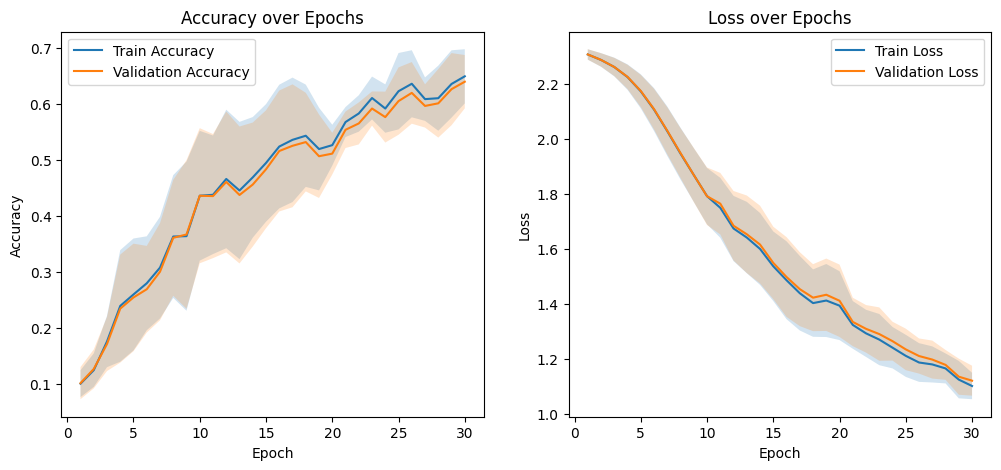


=== Cross Validation Results ===
Average Precision: 0.641063717255684
Average Recall: 0.64
Average F1: 0.5877493508428218


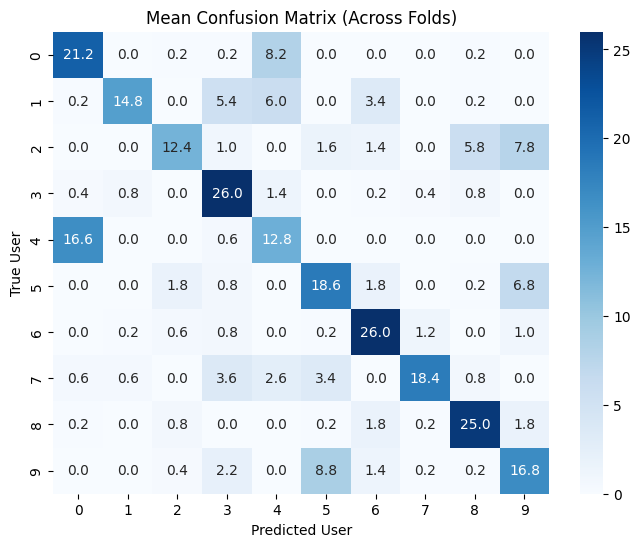

In [29]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(mean_train_loss)+1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, mean_train_acc, label="Train Accuracy")
plt.fill_between(epochs_range,
                 mean_train_acc-std_train_acc,
                 mean_train_acc+std_train_acc,
                 alpha=0.2)

plt.plot(epochs_range, mean_val_acc, label="Validation Accuracy")
plt.fill_between(epochs_range,
                 mean_val_acc-std_val_acc,
                 mean_val_acc+std_val_acc,
                 alpha=0.2)

plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, mean_train_loss, label="Train Loss")
plt.fill_between(epochs_range,
                 mean_train_loss-std_train_loss,
                 mean_train_loss+std_train_loss,
                 alpha=0.2)

plt.plot(epochs_range, mean_val_loss, label="Validation Loss")
plt.fill_between(epochs_range,
                 mean_val_loss-std_val_loss,
                 mean_val_loss+std_val_loss,
                 alpha=0.2)

plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ----- AFTER CROSS VALIDATION -----

print("\n=== Cross Validation Results ===")
print("Average Precision:", np.mean(precisions))
print("Average Recall:", np.mean(recalls))
print("Average F1:", np.mean(f1s))


# Mean confusion matrix
mean_cm = np.mean(cms, axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(mean_cm, annot=True, fmt=".1f", cmap="Blues")
plt.title("Mean Confusion Matrix (Across Folds)")
plt.xlabel("Predicted User")
plt.ylabel("True User")
plt.show()

The LSTM model shows a steady improvement in both training and validation accuracy over epochs, increasing from approximately 10% (random baseline for a 10-class problem) to around 60–70%. The loss curves consistently decrease from about 2.3 to nearly 1.1, indicating that the model is learning meaningful patterns in the time-series sensor data. The close alignment between training and validation curves suggests that the model generalizes reasonably well without severe overfitting.

## 3 Experiment II - User Verification (1-vs-1 Authentication)

In [30]:
import numpy as np
verification_sets = {}

for user in range(10):

    genuine_idx = np.where(y_encoded == user)[0]
    impostor_idx = np.where(y_encoded != user)[0]

    # balance dataset (downsample impostors)
    impostor_sample = np.random.choice(impostor_idx, size=len(genuine_idx), replace=False)

    idx = np.concatenate([genuine_idx, impostor_sample])

    Xf = X_selected[idx]
    Xl = X_lstm[idx]

    y_bin = np.zeros(len(idx))
    y_bin[:len(genuine_idx)] = 1  # genuine = 1

    verification_sets[user] = (Xf, Xl, y_bin)

FNN Verification training

In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

results_fnn = []

for user in range(10):

    print(f"\nTraining verification model for user {user}")

    Xf, _, y = verification_sets[user]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for fold,(train_idx,test_idx) in enumerate(kf.split(Xf,y)):

        print(f"  Fold {fold+1}")

        Xtr, Xte = Xf[train_idx], Xf[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        model = MLPClassifier(
            hidden_layer_sizes=(5,5),
            activation="relu",
            max_iter=500,
            random_state=42
        )

        model.fit(Xtr,ytr)

        probs = model.predict_proba(Xte)[:,1]

        scores.append((yte,probs))

    results_fnn.append(scores)


Training verification model for user 0
  Fold 1
  Fold 2


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 3
  Fold 4


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 5

Training verification model for user 1
  Fold 1


...

c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 2
  Fold 3


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 4
  Fold 5


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [25]:
from sklearn.metrics import roc_curve, auc
import numpy as np

def compute_metrics(y_true, scores):

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, scores)

    # AUC
    auc_score = auc(fpr, tpr)

    # EER
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_index] + fnr[eer_index]) / 2

    # FAR / FRR at threshold 0.5
    threshold = 0.5
    preds = (scores >= threshold).astype(int)

    impostor = (y_true == 0)
    genuine = (y_true == 1)

    FAR = np.sum((preds == 1) & impostor) / np.sum(impostor)
    FRR = np.sum((preds == 0) & genuine) / np.sum(genuine)

    return FAR, FRR, eer, auc_score

far_list = []
frr_list = []
eer_list = []
auc_list = []

for user_scores in results_fnn:

    for y_true, scores in user_scores:

        far,frr,eer,auc_score = compute_metrics(y_true,scores)

        far_list.append(far)
        frr_list.append(frr)
        eer_list.append(eer)
        auc_list.append(auc_score)

print("Average FAR:",np.mean(far_list))
print("Average FRR:",np.mean(frr_list))
print("Average EER:",np.mean(eer_list))
print("Average AUC:",np.mean(auc_list))

Average FAR: 0.032
Average FRR: 0.042
Average EER: 0.016999999999999994
Average AUC: 0.9920888888888889


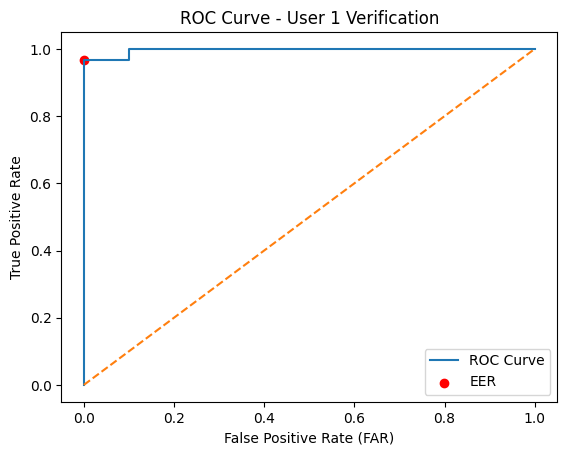

In [26]:
import matplotlib.pyplot as plt

y_true, scores = results_fnn[0][0]

fpr, tpr, _ = roc_curve(y_true, scores)
fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fpr - fnr))
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(fpr[eer_index], tpr[eer_index], color='red', label="EER")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate (FAR)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - User 1 Verification")
plt.legend()
plt.show()

### LSTM Model and Design

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import StratifiedKFold

In [28]:
results_lstm = []

for user in range(10):

    print(f"\nTraining LSTM verification model for user {user}")

    _, Xl, y = verification_sets[user]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for fold,(train_idx,test_idx) in enumerate(kf.split(Xl,y)):

        print(f"  Fold {fold+1}")

        Xtr, Xte = Xl[train_idx], Xl[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        model = Sequential([
            LSTM(32, input_shape=(Xtr.shape[1], Xtr.shape[2])),
            Dense(1, activation="sigmoid")
        ])

        model.compile(
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(Xtr, ytr, epochs=10, batch_size=32, verbose=0)

        probs = model.predict(Xte).flatten()

        scores.append((yte, probs))

    results_lstm.append(scores)


Training LSTM verification model for user 0
  Fold 1


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
  Fold 2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
  Fold 3
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001CF0246F6A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
  Fold 4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
  Fold 5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

Training L

c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
  Fold 2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
  Fold 3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
  Fold 4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
  Fold 5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

Training LSTM verification model for user 2
  Fold 1


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
  Fold 2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
  Fold 3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
  Fold 4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
  Fold 5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

Training LSTM verification model for user 8
  Fold 1


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
  Fold 2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
  Fold 3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
  Fold 4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
  Fold 5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

Training LSTM verification model for user 9
  Fold 1


c:\Users\leeja\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
  Fold 2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
  Fold 3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
  Fold 4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
  Fold 5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


### Cross Validation

In [29]:
from sklearn.metrics import roc_curve, auc
import numpy as np

def compute_metrics(y_true, scores):

    fpr, tpr, thresholds = roc_curve(y_true, scores)

    auc_score = auc(fpr, tpr)

    fnr = 1 - tpr
    eer_index = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_index] + fnr[eer_index]) / 2

    threshold = 0.5
    preds = (scores >= threshold).astype(int)

    impostor = (y_true == 0)
    genuine = (y_true == 1)

    FAR = np.sum((preds == 1) & impostor) / np.sum(impostor)
    FRR = np.sum((preds == 0) & genuine) / np.sum(genuine)

    return FAR, FRR, eer, auc_score

Computing for all users

In [30]:
far_list = []
frr_list = []
eer_list = []
auc_list = []

for user_scores in results_lstm:

    for y_true, scores in user_scores:

        far,frr,eer,auc_score = compute_metrics(y_true,scores)

        far_list.append(far)
        frr_list.append(frr)
        eer_list.append(eer)
        auc_list.append(auc_score)

print("Average FAR:",np.mean(far_list))
print("Average FRR:",np.mean(frr_list))
print("Average EER:",np.mean(eer_list))
print("Average AUC:",np.mean(auc_list))

Average FAR: 0.06199999999999999
Average FRR: 0.024666666666666667
Average EER: 0.047666666666666656
Average AUC: 0.986377777777778


Here it shows the FAR which is how many imposters are accepted around 6.19%. The FRR is the real ones being rejected which is 2.47%. The EER is 4.77%.

ROC plot 

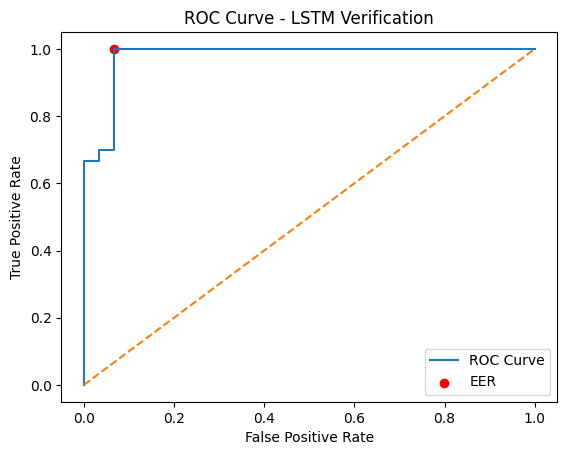

In [31]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_true, scores = results_lstm[0][0]

fpr, tpr, _ = roc_curve(y_true, scores)

fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fpr - fnr))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.scatter(fpr[eer_index], tpr[eer_index], color='red', label="EER")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Verification")
plt.legend()
plt.show()